# Phase 5 — Combined ROC Figures (All 7 Methods)

Generates chunk-level and segment-level ROC figures that include all baselines:
Energy, Wavelet, Cyclo, Cascade, AED-global, AED-perseg, CNN.

**Prerequisites:** run `phase4_cnn_baseline.ipynb` first to generate:
- `results/review_1/cnn_oof_seg_scores.npy`
- `results/review_1/cnn_oof_seg_labels.npy`
- `results/review_1/cnn_oof_chunk_probs.npy`
- `results/review_1/cnn_oof_chunk_labels.npy`

**Outputs:**
- `results/review_1/main_roc_chunk_full.png` — chunk-level ROC, 6 methods
- `results/review_1/main_roc_segment_full.png` — segment-level ROC, 7 methods

**Note on AED-global:** AED-global is a linear (monotone) transform of the Energy score,
so its ROC curve is guaranteed identical to Energy. Both are shown to make this equivalence
explicit in the figure.

**Expected runtime: ~5–10 min (classical detectors, CPU)**

In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path
from dotenv import load_dotenv
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT / "src"))

from rfml_uav.drone_rf.consts import BUI, FS_HZ
from rfml_uav.drone_rf.utils import get_segment_count, get_binary_label
from rfml_uav.signal_detection.methods import (
    energy_detector,
    wavelet_detector,
    cyclo_detector,
)
from rfml_uav.signal_detection.cascade import cascade_detector

load_dotenv()
CHUNKED_PATH = Path(os.getenv("DATA_PATH")) / "chunked"
OUT = ROOT / "results" / "review_1"
OUT.mkdir(parents=True, exist_ok=True)

FIXED_PFA     = 0.05
N_CHUNK       = 4000
MIN_BURST_LEN = 50

SIGNAL_BUIS = [b for b in BUI if get_binary_label(b) == 1]
NOISE_BUIS  = [b for b in BUI if get_binary_label(b) == 0]
# Process in same order as phase4 (signal first, then noise) so chunk indices align
ALL_BUIS = [(b, 1) for b in SIGNAL_BUIS] + [(b, 0) for b in NOISE_BUIS]

def duration_constrained_score(scores, min_duration=0.10):
    k = max(1, int(np.ceil(min_duration / (N_CHUNK / FS_HZ))))
    if len(scores) <= k:
        return float(np.mean(scores))
    return float(np.mean(np.sort(scores)[-k:]))

print(f"ROOT         : {ROOT}")
print(f"CHUNKED_PATH : {CHUNKED_PATH}")
print(f"Signal BUIs  : {SIGNAL_BUIS}")
print(f"Noise BUIs   : {NOISE_BUIS}")

ROOT         : /home/ivan/work/ml/rfml-uav
CHUNKED_PATH : /home/ivan/work/ml/rfml-uav/data/drone-rf/chunked
Signal BUIs  : ['10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000']
Noise BUIs   : ['00000']


---
## Background calibration

Compute energy threshold (Pfa=0.05) and AED background statistics
from the background-only BUI `00000`.

In [2]:
print("Calibrating background statistics...")
bg_scores = []
for seg in range(get_segment_count("00000")):
    for fp in sorted(glob(str(CHUNKED_PATH / f"00000*_{seg}.npz"))):
        chunks = np.load(fp)["arr_0"]
        for x in chunks:
            bg_scores.append(energy_detector(x))

bg_arr    = np.array(bg_scores)
thr_energy = np.percentile(bg_arr, 100 * (1 - FIXED_PFA))
AED_MU    = np.median(bg_arr)
AED_SIGMA = max(np.median(np.abs(bg_arr - AED_MU)) * 1.4826, 1e-10)

print(f"Background chunks : {len(bg_arr):,}")
print(f"Energy threshold  : {thr_energy:.4f}  (Pfa={FIXED_PFA})")
print(f"AED mu            : {AED_MU:.4f}")
print(f"AED sigma         : {AED_SIGMA:.6f}")

Calibrating background statistics...
Background chunks : 205,000
Energy threshold  : 14.7695  (Pfa=0.05)
AED mu            : 5.9463
AED sigma         : 0.278358


---
## Main scoring loop — classical and AED methods

Collects per-chunk scores (for chunk-level ROC) and per-segment
duration-constrained scores (for segment-level ROC) for all 6 classical/AED methods.

BUI processing order matches `phase4_cnn_baseline.ipynb` (signal BUIs first, then noise)
so chunk indices align when CNN scores are loaded.

In [3]:
chunk_scores = {k: [] for k in ["Energy", "Wavelet", "Cyclo", "AED-global", "AED-perseg"]}
chunk_labels = []

segment_scores = {k: [] for k in
                  ["Energy", "Wavelet", "Cyclo", "Cascade", "AED-global", "AED-perseg"]}
segment_labels = []

for bui, label in tqdm(ALL_BUIS, desc="Scoring"):
    for seg in range(get_segment_count(bui)):
        files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
        if not files:
            continue

        seg_energy  = []
        seg_wavelet = []
        seg_cyclo   = []
        cascade_file_scores = []
        chunk_len = None

        for fp in files:
            data = np.load(fp)["arr_0"]
            chunk_len = len(data[0])

            for x in data:
                seg_energy.append(energy_detector(x))
                seg_wavelet.append(wavelet_detector(x))
                seg_cyclo.append(cyclo_detector(x, fs=FS_HZ))
                chunk_labels.append(label)

            c_score, _, _ = cascade_detector(
                chunks=data, fs=FS_HZ,
                thr=thr_energy, min_burst_len=MIN_BURST_LEN,
                return_meta=True)
            cascade_file_scores.append(c_score)

        if not seg_energy:
            continue

        e_arr   = np.array(seg_energy)

        # AED-global: background-calibrated z-score (linear transform of energy)
        aed_g = ((e_arr - AED_MU) / AED_SIGMA).tolist()

        # AED-perseg: within-segment noise floor (25th-percentile + MAD)
        mu_p    = np.percentile(e_arr, 25)
        mad_p   = np.median(np.abs(e_arr - np.median(e_arr)))
        sigma_p = max(mad_p * 1.4826, 1e-10)
        aed_p   = ((e_arr - mu_p) / sigma_p).tolist()

        chunk_scores["Energy"].extend(seg_energy)
        chunk_scores["Wavelet"].extend(seg_wavelet)
        chunk_scores["Cyclo"].extend(seg_cyclo)
        chunk_scores["AED-global"].extend(aed_g)
        chunk_scores["AED-perseg"].extend(aed_p)

        segment_scores["Energy"].append(duration_constrained_score(seg_energy))
        segment_scores["Wavelet"].append(duration_constrained_score(seg_wavelet))
        segment_scores["Cyclo"].append(duration_constrained_score(seg_cyclo))
        segment_scores["Cascade"].append(max(cascade_file_scores))
        segment_scores["AED-global"].append(duration_constrained_score(aed_g))
        segment_scores["AED-perseg"].append(duration_constrained_score(aed_p))
        segment_labels.append(label)

chunk_labels   = np.array(chunk_labels)
segment_labels = np.array(segment_labels)
for k in chunk_scores:
    chunk_scores[k] = np.array(chunk_scores[k])
for k in segment_scores:
    segment_scores[k] = np.array(segment_scores[k])

print(f"Chunks   : {len(chunk_labels):,}  "
      f"(signal={chunk_labels.sum():,}, noise={(1-chunk_labels).sum():,})")
print(f"Segments : {len(segment_labels)}  "
      f"(signal={segment_labels.sum()}, noise={(1-segment_labels).sum()})")

Scoring: 100%|██████████| 10/10 [12:27<00:00, 74.75s/it]

Chunks   : 1,349,460  (signal=1,144,460, noise=205,000)
Segments : 227  (signal=186, noise=41)


---
## Load CNN OOF scores

OOF scores saved by `phase4_cnn_baseline.ipynb`. Segment ordering matches this notebook
because both use `SIGNAL_BUIS + NOISE_BUIS` processed in the same order.

In [4]:
cnn_chunk_probs  = np.load(OUT / "cnn_oof_chunk_probs.npy")
cnn_chunk_labels = np.load(OUT / "cnn_oof_chunk_labels.npy")
cnn_seg_scores   = np.load(OUT / "cnn_oof_seg_scores.npy")
cnn_seg_labels   = np.load(OUT / "cnn_oof_seg_labels.npy")

# Verify alignment
assert len(cnn_chunk_probs) == len(chunk_labels), (
    f"Chunk count mismatch: CNN={len(cnn_chunk_probs)}, classical={len(chunk_labels)}. "
    "Re-run phase4_cnn_baseline.ipynb.")
assert len(cnn_seg_scores) == len(segment_labels), (
    f"Segment count mismatch: CNN={len(cnn_seg_scores)}, classical={len(segment_labels)}.")
assert np.array_equal(cnn_chunk_labels, chunk_labels), (
    "Chunk label mismatch — BUI processing order differs between phase4 and phase5.")
assert np.array_equal(cnn_seg_labels, segment_labels), (
    "Segment label mismatch.")

print(f"CNN OOF loaded successfully.")
print(f"  Segments : {len(cnn_seg_scores)}")
print(f"  Chunks   : {len(cnn_chunk_probs):,}")

CNN OOF loaded successfully.
  Segments : 227
  Chunks   : 1,349,460


---
## Chunk-level ROC — all methods

Each point is a single 4000-sample chunk. Label = 1 if chunk belongs to a signal BUI.

AED-global ROC overlaps Energy exactly (linear monotone transform → identical ROC).
Both are plotted to make the equivalence visible.

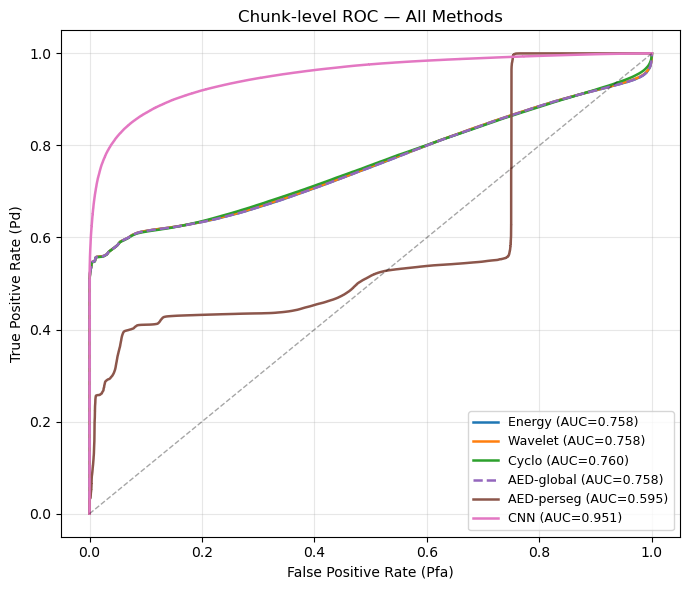

Saved: main_roc_chunk_full.png


In [5]:
METHOD_COLORS = {
    "Energy":    "#1f77b4",
    "Wavelet":   "#ff7f0e",
    "Cyclo":     "#2ca02c",
    "AED-global": "#9467bd",
    "AED-perseg": "#8c564b",
    "CNN":        "#e377c2",
}

fig, ax = plt.subplots(figsize=(7, 6))

for name, scores in chunk_scores.items():
    fpr, tpr, _ = roc_curve(chunk_labels, scores)
    roc_auc = auc(fpr, tpr)
    ls = "--" if name == "AED-global" else "-"  # dashed to show overlap with Energy
    ax.plot(fpr, tpr, color=METHOD_COLORS[name], linewidth=1.8,
            linestyle=ls, label=f"{name} (AUC={roc_auc:.3f})")

fpr_c, tpr_c, _ = roc_curve(cnn_chunk_labels, cnn_chunk_probs)
ax.plot(fpr_c, tpr_c, color=METHOD_COLORS["CNN"], linewidth=1.8,
        label=f"CNN (AUC={auc(fpr_c, tpr_c):.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.35, linewidth=1)
ax.set_xlabel("False Positive Rate (Pfa)")
ax.set_ylabel("True Positive Rate (Pd)")
ax.set_title("Chunk-level ROC — All Methods")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "main_roc_chunk_full.png", dpi=150)
plt.show()
print(f"Saved: main_roc_chunk_full.png")

---
## Segment-level ROC — all methods

Each point is a full recording segment. Score = duration-constrained aggregate of
chunk scores (top-k mean, k = ceil(0.1 s / chunk_duration)).
Cascade uses max score across .npz files within a segment.

CNN score uses the same duration-constrained aggregation of OOF chunk probabilities.

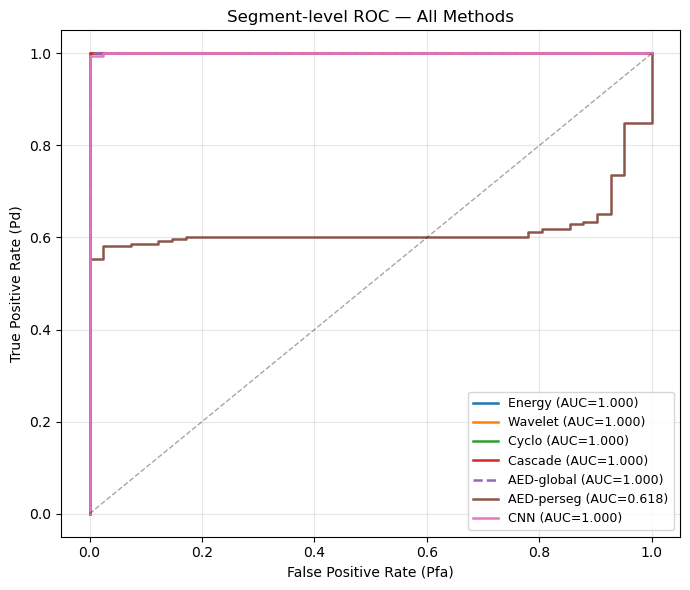

Saved: main_roc_segment_full.png


In [6]:
SEG_COLORS = {
    "Energy":    "#1f77b4",
    "Wavelet":   "#ff7f0e",
    "Cyclo":     "#2ca02c",
    "Cascade":   "#d62728",
    "AED-global": "#9467bd",
    "AED-perseg": "#8c564b",
    "CNN":        "#e377c2",
}

fig, ax = plt.subplots(figsize=(7, 6))

for name, scores in segment_scores.items():
    fpr, tpr, _ = roc_curve(segment_labels, scores)
    roc_auc = auc(fpr, tpr)
    ls = "--" if name == "AED-global" else "-"
    ax.plot(fpr, tpr, color=SEG_COLORS[name], linewidth=1.8,
            linestyle=ls, label=f"{name} (AUC={roc_auc:.3f})")

fpr_cs, tpr_cs, _ = roc_curve(cnn_seg_labels, cnn_seg_scores)
ax.plot(fpr_cs, tpr_cs, color=SEG_COLORS["CNN"], linewidth=1.8,
        label=f"CNN (AUC={auc(fpr_cs, tpr_cs):.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.35, linewidth=1)
ax.set_xlabel("False Positive Rate (Pfa)")
ax.set_ylabel("True Positive Rate (Pd)")
ax.set_title("Segment-level ROC — All Methods")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "main_roc_segment_full.png", dpi=150)
plt.show()
print(f"Saved: main_roc_segment_full.png")

---
## Pd @ Pfa=0.05 summary table

In [7]:
print(f"{'Method':<14} {'Chunk Pd':>10} {'Chunk AUC':>11} {'Seg Pd':>9} {'Seg AUC':>10}")
print("-" * 58)

all_chunk = {**chunk_scores, "CNN": cnn_chunk_probs}
all_seg   = {**segment_scores, "CNN": cnn_seg_scores}
all_cl    = {k: chunk_labels   for k in all_chunk}
all_sl    = {k: segment_labels for k in all_seg}
all_cl["CNN"] = cnn_chunk_labels
all_sl["CNN"] = cnn_seg_labels

for name in ["Energy", "Wavelet", "Cyclo", "Cascade", "AED-global", "AED-perseg", "CNN"]:
    # chunk
    if name in all_chunk:
        fpr, tpr, _ = roc_curve(all_cl[name], all_chunk[name])
        ok  = np.where(fpr <= FIXED_PFA)[0]
        cpd = float(tpr[ok[np.argmax(tpr[ok])]]) if len(ok) else 0.0
        cauc = float(auc(fpr, tpr))
    else:
        cpd = cauc = float("nan")
    # segment
    fpr, tpr, _ = roc_curve(all_sl[name], all_seg[name])
    ok  = np.where(fpr <= FIXED_PFA)[0]
    spd = float(tpr[ok[np.argmax(tpr[ok])]]) if len(ok) else 0.0
    sauc = float(auc(fpr, tpr))
    print(f"{name:<14} {cpd:>10.3f} {cauc:>11.3f} {spd:>9.3f} {sauc:>10.3f}")

Method           Chunk Pd   Chunk AUC    Seg Pd    Seg AUC
----------------------------------------------------------
Energy              0.584       0.758     1.000      1.000
Wavelet             0.584       0.758     1.000      1.000
Cyclo               0.584       0.760     1.000      1.000
Cascade               nan         nan     1.000      1.000
AED-global          0.584       0.758     1.000      1.000
AED-perseg          0.343       0.595     0.581      0.618
CNN                 0.820       0.951     1.000      1.000
